# Iterative Radiomics-Guided Region Growing Algorithm



## Objective

Implement an iterative region growing algorithm using voxel-based PyRadiomics features on SPECT tumor images.

## Algorithm Overview

1. **Load SPECT DICOM Study**: Import full 3D DICOM series using SimpleITK
2. **Extract & Display Coronal Slice**: Select a specific coronal plane for analysis
3. **Define Working ROI**: Crop the coronal slice to the region of interest
4. **Create Initial Lesion Mask**: Apply intensity thresholding to identify potential lesion
5. **Compute Reference Radiomic Map**: Extract voxel-based Median map inside initial ROI (ROI0)
6. **Establish Statistical Limits**: Use ROI0 distribution as fixed reference (mean ± k*std)
7. **Iterative Region Growing**:
   - Dilate current ROI to generate candidate voxels (corona)
   - Compute voxel-based Median for dilated region
   - Classify each voxel: accept if within statistical bounds
   - Update ROI with accepted voxels
   - Repeat for N iterations
8. **Generate Results & Visualizations**

## Key Implementation Details

- **Radiomic Feature**: `firstorder.Median` (voxel-based)
- **Reference Distribution**: Fixed throughout all iterations
- **PyRadiomics Coordinate Handling**: Automatic reconstruction from bounding-box to full-image coordinates
- **Configurable Parameters**: Threshold percentage, k-value, number of iterations

In [1]:
# ==============================================================================
# 1. IMPORTS & SETUP
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk
from pathlib import Path
from scipy.ndimage import binary_dilation
from radiomics import featureextractor
import matplotlib.patches as patches
import pydicom
import seaborn as sns


## Variable parameters

### 1. **Threshold**
### 2. **k_value**
### 3. **Caracteristica radiomica**

In [2]:
# ==============================================================================
# 2. CONFIGURATION & PARAMETERS
# ============================================================================== 

# Data paths
DATA_DIR = Path("PSMAB37")
SPECT_DIR = DATA_DIR / "SPECT"

# Imaging parameters
CORONAL_SLICE = 137          # Coronal slice index to extract
ROI_CROP = (220, 140)        # (row_start, col_start) for working region cropping

# Thresholding parameters
THRESHOLD_PERCENTILE = 0.70  # Initial mask: percentage of max intensity

# Radiomic parameters
FEATURE_CLASS = "firstorder"  # Only firstorder features are supported in current pipeline
FEATURE_NAME = "Median"      # Example values: Median, Mean, Entropy, Energy
FEATURE_KEY = f"original_{FEATURE_CLASS}_{FEATURE_NAME}"

K_VALUE = 10                 # Acceptance limits: mean ± k*std
NUM_ITERATIONS = 15          # Number of region-growing iterations

print(f" Configuration loaded:")
print(f"  - SPECT directory: {SPECT_DIR}")
print(f"  - Coronal slice: {CORONAL_SLICE}")
print(f"  - ROI crop offset: {ROI_CROP}")
print(f"  - Radiomic feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - K-value (acceptance bounds): {K_VALUE}")
print(f"  - Iterations: {NUM_ITERATIONS}")

 Configuration loaded:
  - SPECT directory: PSMAB37\SPECT
  - Coronal slice: 137
  - ROI crop offset: (220, 140)
  - Radiomic feature: firstorder.Median
  - K-value (acceptance bounds): 10
  - Iterations: 15


## Stage 1: Data Loading & Preparation

In [3]:
# Load SPECT DICOM series
reader = sitk.ImageSeriesReader()
files = reader.GetGDCMSeriesFileNames(str(SPECT_DIR))
reader.SetFileNames(files)
spect_img = reader.Execute()# este es el objeto de imagen de SPECT en SimpleITK

spect_array = sitk.GetArrayFromImage(spect_img)# este es la imagen de SPECT en un array de numpy

print(f" SPECT series loaded")
print(f"  - Shape: {spect_array.shape}")#Formato: (z, y, x) para imágenes 3D
print(f"  - Size: {spect_img.GetSize()}")#Formato: (x, y, z) para imágenes 3D
print(f"  - Spacing: {spect_img.GetSpacing()}") #Devuelve el tamaño físico de cada voxel en milímetros (x_spacing, y_spacing, z_spacing)
print(f"  - Range: [{spect_array.min():.2f}, {spect_array.max():.2f}]") #Muestra los valores mínimo y máximo de intensidad de la imagen.

 SPECT series loaded
  - Shape: (299, 256, 256)
  - Size: (256, 256, 299)
  - Spacing: (2.734375, 2.734375, 3.270000022529765)
  - Range: [0.00, 52344.30]


 Coronal slice extracted and processed
  - Coronal slice index: 137
  - Full coronal shape: (299, 256)
  - Working ROI shape: (79, 116)
  - ROI intensity range: [0.00, 19446.12]


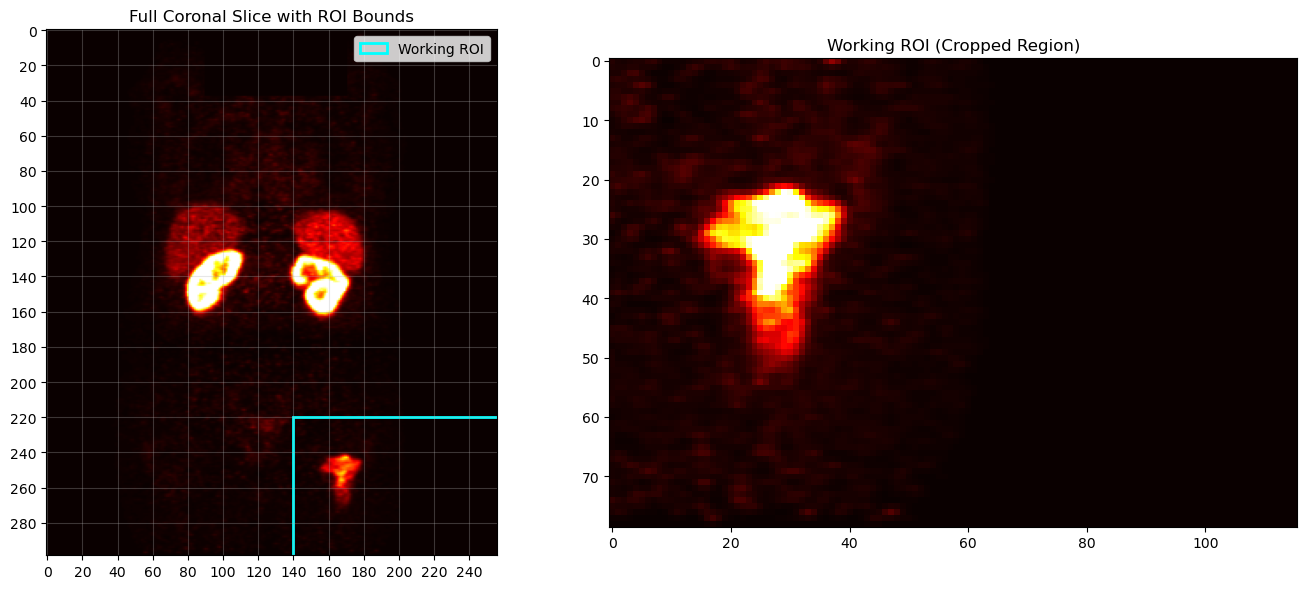

In [4]:
# Extract and display coronal slice
coronal_raw = spect_array[:, CORONAL_SLICE, :]#
coronal_vis = np.fliplr(np.rot90(coronal_raw, 2))# SE ROTAN 180 GRADOS Y SE VOLTEA HORIZONTALMENTE PARA QUE LA IMAGEN CORONAL SE VISUALICE CORRECTAMENTE


# Crop to working region
roi_img = coronal_vis[ROI_CROP[0]:, ROI_CROP[1]:]# se recorta la imagen coronal para obtener la región de interés (ROI) a partir de las coordenadas especificadas en ROI_CROP

print(f" Coronal slice extracted and processed")
print(f"  - Coronal slice index: {CORONAL_SLICE}")
print(f"  - Full coronal shape: {coronal_vis.shape}")
print(f"  - Working ROI shape: {roi_img.shape}")
print(f"  - ROI intensity range: [{roi_img.min():.2f}, {roi_img.max():.2f}]")

# Visualize working ROI
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full coronal image
axes[0].imshow(
    coronal_vis,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(coronal_vis, 99)
)

# Coordinate grid
axes[0].set_xticks(np.arange(0, coronal_vis.shape[1], 20))
axes[0].set_yticks(np.arange(0, coronal_vis.shape[0], 20))
axes[0].grid(True, alpha=0.3)

# ROI rectangle
roi_rect = patches.Rectangle(
    (ROI_CROP[1], ROI_CROP[0]),               # (x, y)
    coronal_vis.shape[1] - ROI_CROP[1],      # width
    coronal_vis.shape[0] - ROI_CROP[0],      # height
    linewidth=2,
    edgecolor="cyan",
    facecolor="none",
    label="Working ROI"
)

axes[0].add_patch(roi_rect)

axes[0].set_title("Full Coronal Slice with ROI Bounds")
axes[0].legend()

# Cropped ROI
axes[1].imshow(
    roi_img,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(roi_img, 99)
)

axes[1].set_title("Working ROI (Cropped Region)")
axes[1].axis("on")

plt.tight_layout()
plt.show()

### ____________________________________________________________________________-

✓ Manual segmentation loaded
  - Segmented voxels (3D): 4828
  - Segmented pixels in ROI: 318


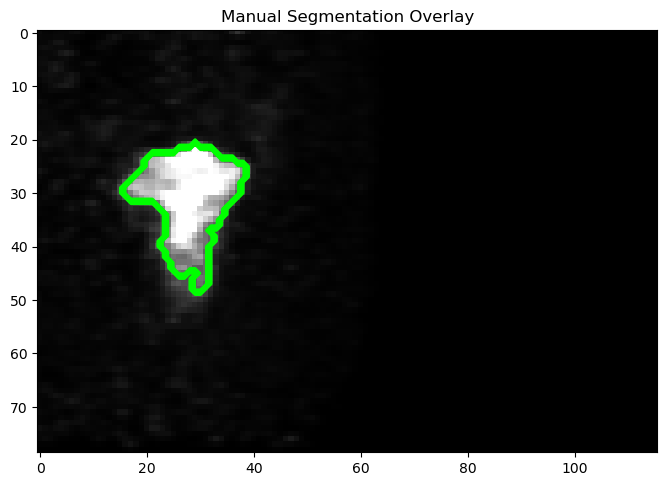

In [5]:
# ==============================================================================
# ! Stage 1.5: Load Manual Segmentation (DICOM SEG)
# ==============================================================================

SEG_PATH = DATA_DIR / "SEGMENTATIONS" / "1-1.dcm"

def load_manual_segmentation(
    seg_path,
    spect_dir,
    spect_array,
    coronal_slice,
    roi_crop
):
    """
    Load DICOM SEG, reconstruct full 3D segmentation volume,
    extract the same coronal plane used by the algorithm,
    and apply identical visualization transforms and ROI crop.
    """

    # Load SEG object
    seg = pydicom.dcmread(str(seg_path))
    seg_array = seg.pixel_array.astype(np.uint8)

    # Build UID -> slice index map from SPECT series
    spect_files = sorted(Path(spect_dir).glob("*.dcm"))

    uid_to_slice = {}

    for idx, f in enumerate(spect_files):

        ds = pydicom.dcmread(
            str(f),
            stop_before_pixels=True
        )

        uid_to_slice[ds.SOPInstanceUID] = idx

    # Determine which SPECT slice corresponds to each SEG frame
    seg_slices = []

    for frame in seg.PerFrameFunctionalGroupsSequence:

        uid = (
            frame.DerivationImageSequence[0]
            .SourceImageSequence[0]
            .ReferencedSOPInstanceUID
        )

        if uid in uid_to_slice:
            seg_slices.append(uid_to_slice[uid])

    # Reconstruct full 3D segmentation volume
    manual_mask_3d = np.zeros_like(
        spect_array,
        dtype=np.uint8
    )

    for frame_idx, spect_idx in enumerate(seg_slices):
        manual_mask_3d[spect_idx] = seg_array[frame_idx]

    # Extract same coronal plane
    manual_coronal_raw = manual_mask_3d[:, coronal_slice, :]

    # Apply same visualization orientation
    manual_coronal_vis = np.flipud(
        np.fliplr(
            np.rot90(manual_coronal_raw, 2)
        )
    )

    # Apply same ROI crop
    manual_mask_roi = manual_coronal_vis[
        roi_crop[0]:,
        roi_crop[1]:
    ]

    return (
        manual_mask_3d,
        manual_coronal_vis,
        manual_mask_roi
    )

# Load manual segmentation
manual_mask_3d, manual_coronal_vis, manual_mask_roi = (
    load_manual_segmentation(
        SEG_PATH,
        SPECT_DIR,
        spect_array,
        CORONAL_SLICE,
        ROI_CROP
    )
)

print("✓ Manual segmentation loaded")
print(f"  - Segmented voxels (3D): {manual_mask_3d.sum()}")
print(f"  - Segmented pixels in ROI: {manual_mask_roi.sum()}")

# Visual verification

plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img, 99)
)

plt.contour(
    manual_mask_roi,
    colors="lime",
    linewidths=2
)

plt.title("Manual Segmentation Overlay")
plt.show()

### _____________________________________________________________________________________________

## Stage 2: Initial Lesion Mask (ROI0)

 Initial mask (ROI0) created
  - Threshold: 70% of max = 13612.28
  - Mask size: 53 voxels


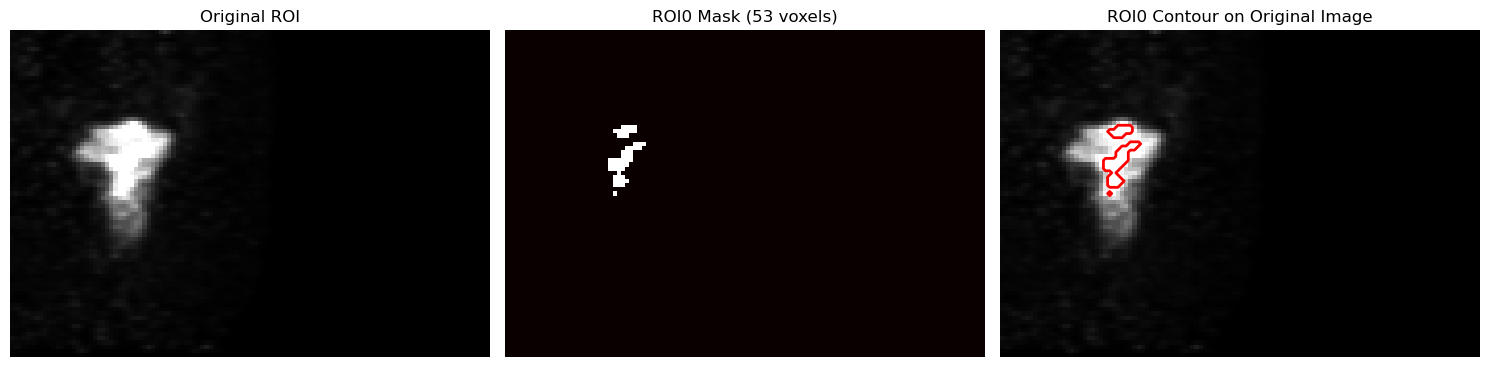

In [6]:
# Create initial lesion mask (ROI0)
threshold = THRESHOLD_PERCENTILE * roi_img.max() 
mask0 = roi_img > threshold # todo voxel con intensidad mayor al umbral se considera parte de la lesión y se marca como True en la máscara binaria mask0

print(f" Initial mask (ROI0) created")
print(f"  - Threshold: {THRESHOLD_PERCENTILE * 100:.0f}% of max = {threshold:.2f}")
print(f"  - Mask size: {mask0.sum()} voxels")

# Visualize initial mask
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].set_title("Original ROI")
axes[0].axis('off')

axes[1].imshow(mask0, cmap="hot")
axes[1].set_title(f"ROI0 Mask ({mask0.sum()} voxels)")
axes[1].axis('off')

axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='r', linewidths=2)
axes[2].set_title("ROI0 Contour on Original Image")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Stage 3: PyRadiomics Setup & Utility Functions

In [7]:
# Initialize PyRadiomics feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor()  # Crear una instancia del extractor de PyRadiomics con la configuración por defecto
extractor.disableAllFeatures()  # Desactivar todas las características para evitar cálculos innecesarios
extractor.enableFeaturesByName(**{FEATURE_CLASS: [FEATURE_NAME]})  # Habilitar únicamente la característica especificada (ej. firstorder: Median)

print(f"✓ PyRadiomics extractor initialized") 
print(f"  - Feature: {FEATURE_CLASS}.{FEATURE_NAME}")  
print(f"  - Voxel-based extraction enabled") 

✓ PyRadiomics extractor initialized
  - Feature: firstorder.Median
  - Voxel-based extraction enabled


In [8]:
def reconstruct_voxel_map(result_dict, reference_shape, feature_key):
    """
    result_dict: diccionario de resultados de PyRadiomics que contiene la característica extraída y la bounding box
    reference_shape: la forma de la imagen original
    feature_key: clave de la característica en result_dict (ej. "original_firstorder_M
    
    Tomar el mapa radiomico (que viene en bounding box) y colocarlo de nuevo en 
    la imagen original. ME DA UN ARRAY CON el mapa radiomico voxel-based reubicado en el sistema original de la imagen (80×60), lo que 
    no esta en el bounding box esta llenos de ceros sin filtrar aun con la mascara
    """
    bbox_key = "diagnostics_Mask-original_BoundingBox"  # variable donde PyRadiomics guarda la bounding box
    if bbox_key not in result_dict:  # verifica que la bounding box esté presente en el resultado
        raise ValueError(f"Bounding box not found in result. Available keys: {result_dict.keys()}")  # lanza error si falta
    
    bbox = result_dict[bbox_key]  # extrae la tupla bounding box
    x, y, z, sx, sy, sz = bbox  # desempaqueta las coordenadas y tamaños del bounding box
    
    if feature_key not in result_dict:  # comprueba que la clave de la característica exista en el resultado
        raise ValueError(
            f"Feature key '{feature_key}' not found in result. Available keys: {list(result_dict.keys())}"
        )  # lanza error si la característica no está presente
    feature_img = result_dict[feature_key]  # obtiene la imagen SimpleITK correspondiente a la característica
    median_map = sitk.GetArrayFromImage(feature_img)[0]  # convierte la imagen a numpy y toma la primera (única) z-slice
    
    full_map = np.zeros(reference_shape, dtype=float)  # inicializa el mapa completo con ceros (float)
    
    h, w = median_map.shape  # obtiene alto y ancho del mapa dentro del bounding box
    x0 = x - 1  # convierte la coordenada x de 1-based (PyRadiomics) a 0-based (numpy)
    y0 = y - 1  # convierte la coordenada y de 1-based a 0-based
    
    full_map[
        y0:y0 + h,
        x0:x0 + w
    ] = median_map  # inserta el mapa extraído en la posición correspondiente del mapa completo
    
    return full_map, (x0, y0, h, w)  # devuelve el mapa reconstruido y la información de bounding box ajustada

print("✓ Utility function 'reconstruct_voxel_map' defined")  # confirma que la función ha sido definida


✓ Utility function 'reconstruct_voxel_map' defined


## Stage 4: Reference Distribution (ROI0 Voxel-Based Statistics)

✓ Reference distribution computed from ROI0
  - Feature: original_firstorder_Median
  - Number of voxels: 53
  - Mean: 15442.4533
  - Std: 938.8707
  - Acceptance bounds (k=10):
    • Lower limit: 6053.7459
    • Upper limit: 24831.1607


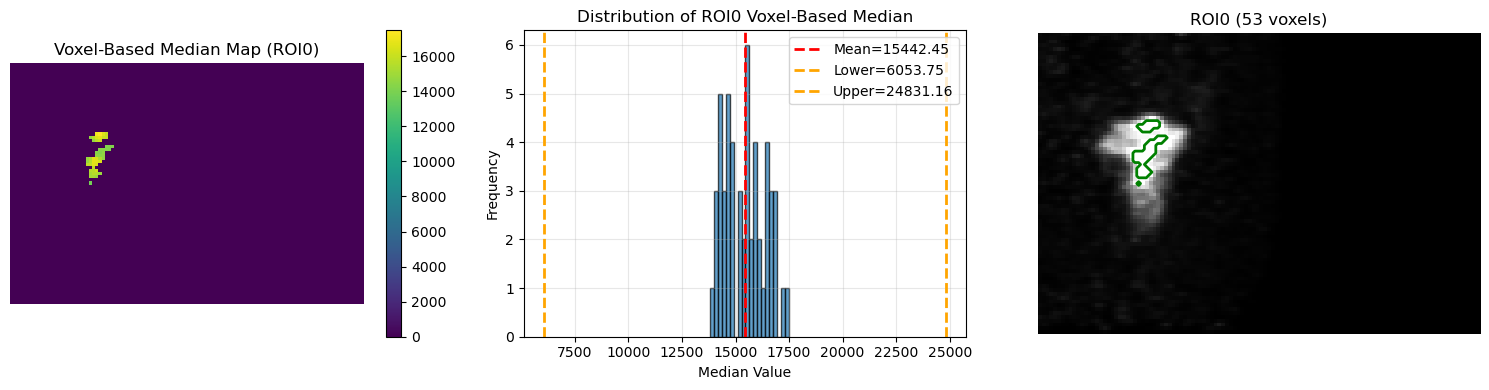

In [9]:
# Extract voxel-based radiomic map for ROI0
# Convert to 3D format required by PyRadiomics
img_3d = roi_img[np.newaxis, :, :].astype(np.float32)
mask0_3d = mask0[np.newaxis, :, :].astype(np.uint8)

sitk_img = sitk.GetImageFromArray(img_3d)
sitk_mask0 = sitk.GetImageFromArray(mask0_3d)

# Extract voxel-based radiomic map
result_roi0 = extractor.execute(sitk_img, sitk_mask0, voxelBased=True)

# Reconstruct full map and extract ROI0 voxel values
voxel_map_roi0, bbox_info = reconstruct_voxel_map(result_roi0, roi_img.shape, FEATURE_KEY)
vals_roi0 = voxel_map_roi0[mask0]  # Extract values only within mask0

# Compute statistics
mean_ref = vals_roi0.mean()
std_ref = vals_roi0.std()

# Define acceptance limits (fixed throughout all iterations)
lower_limit = mean_ref - K_VALUE * std_ref
upper_limit = mean_ref + K_VALUE * std_ref

print(f"✓ Reference distribution computed from ROI0")
print(f"  - Feature: {FEATURE_KEY}")
print(f"  - Number of voxels: {len(vals_roi0)}")
print(f"  - Mean: {mean_ref:.4f}")
print(f"  - Std: {std_ref:.4f}")
print(f"  - Acceptance bounds (k={K_VALUE}):")
print(f"    • Lower limit: {lower_limit:.4f}")
print(f"    • Upper limit: {upper_limit:.4f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(voxel_map_roi0, cmap="viridis")
axes[0].set_title(f"Voxel-Based {FEATURE_NAME} Map (ROI0)")
axes[0].colorbar = plt.colorbar(axes[0].images[0], ax=axes[0])
axes[0].axis('off')

axes[1].hist(vals_roi0, bins=20, edgecolor='k', alpha=0.7)
axes[1].axvline(mean_ref, color='r', linestyle='--', linewidth=2, label=f'Mean={mean_ref:.2f}')
axes[1].axvline(lower_limit, color='orange', linestyle='--', linewidth=2, label=f'Lower={lower_limit:.2f}')
axes[1].axvline(upper_limit, color='orange', linestyle='--', linewidth=2, label=f'Upper={upper_limit:.2f}')
axes[1].set_xlabel(f"{FEATURE_NAME} Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Distribution of ROI0 Voxel-Based {FEATURE_NAME}")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='g', linewidths=2)
axes[2].set_title(f"ROI0 ({mask0.sum()} voxels)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Stage 5: Iterative Region Growing

In [10]:
#!/usr/bin/env python
# Iterative region growing with fixed reference statistics

roi_current = mask0.copy()
results = []
history = []

print(f"Starting iterative region growing ({NUM_ITERATIONS} iterations)...\n")

for iteration in range(1, NUM_ITERATIONS + 1):
    
    # Step 1: Generate candidate voxels via dilation
    roi_dilated = binary_dilation(roi_current)
    corona = roi_dilated & (~roi_current)
    
    # Step 2: Compute voxel-based feature map on dilated ROI
    mask_3d = roi_dilated.astype(np.uint8)[np.newaxis, :, :]
    sitk_mask = sitk.GetImageFromArray(mask_3d)
    
    result = extractor.execute(sitk_img, sitk_mask, voxelBased=True)
    
    # Step 3: Reconstruct full-size map from PyRadiomics bounding box
    full_map, _ = reconstruct_voxel_map(result, roi_img.shape, FEATURE_KEY)
    
    # Step 4: Extract radiomic values for corona voxels
    corona_values = full_map[corona]
    
    # Step 5: Classify voxels (accept if within statistical bounds)
    accepted = (
        (corona_values >= lower_limit) &
        (corona_values <= upper_limit)
    )
    
    # Step 6: Create mask of accepted voxels
    mask_accepted = np.zeros_like(roi_current, dtype=bool)
    mask_accepted[corona] = accepted
    
    # Step 7: Update ROI with accepted voxels
    roi_new = roi_current | mask_accepted
    
    # Step 8: Store results
    n_accepted = accepted.sum()
    n_rejected = (~accepted).sum()
    
    results.append({
        "Iteration": iteration,
        "Current ROI Size": roi_current.sum(),
        "Corona Size": corona.sum(),
        "Accepted": n_accepted,
        "Rejected": n_rejected,
        "New ROI Size": roi_new.sum()
    })
    
    history.append({
        "iteration": iteration,
        "roi_current": roi_current.copy(),
        "roi_dilated": roi_dilated.copy(),
        "corona": corona.copy(),
        "mask_accepted": mask_accepted.copy(),
        "corona_values": corona_values.copy(),
        "voxel_map": full_map.copy()
    })
    
    # Print progress
    size_increase = roi_new.sum() - roi_current.sum()
    print(f"Iter {iteration:2d}: ROI {roi_current.sum():4d} → {roi_new.sum():4d} "
          f"| Corona: {corona.sum():4d} | Acc: {n_accepted:4d} | Rej: {n_rejected:4d} | "
          f"Growth: {size_increase:+4d}")
    
    # Update for next iteration
    roi_current = roi_new

print("\n✓ Iterative region growing completed!")

# Create results DataFrame
df_results = pd.DataFrame(results)
print("\nResults Summary:")
print(df_results)

Starting iterative region growing (15 iterations)...

Iter  1: ROI   53 →  104 | Corona:   51 | Acc:   51 | Rej:    0 | Growth:  +51
Iter  2: ROI  104 →  151 | Corona:   48 | Acc:   47 | Rej:    1 | Growth:  +47
Iter  3: ROI  151 →  184 | Corona:   49 | Acc:   33 | Rej:   16 | Growth:  +33
Iter  4: ROI  184 →  208 | Corona:   51 | Acc:   24 | Rej:   27 | Growth:  +24
Iter  5: ROI  208 →  233 | Corona:   54 | Acc:   25 | Rej:   29 | Growth:  +25
Iter  6: ROI  233 →  252 | Corona:   57 | Acc:   19 | Rej:   38 | Growth:  +19
Iter  7: ROI  252 →  264 | Corona:   61 | Acc:   12 | Rej:   49 | Growth:  +12
Iter  8: ROI  264 →  271 | Corona:   64 | Acc:    7 | Rej:   57 | Growth:   +7
Iter  9: ROI  271 →  275 | Corona:   65 | Acc:    4 | Rej:   61 | Growth:   +4
Iter 10: ROI  275 →  279 | Corona:   65 | Acc:    4 | Rej:   61 | Growth:   +4
Iter 11: ROI  279 →  282 | Corona:   65 | Acc:    3 | Rej:   62 | Growth:   +3
Iter 12: ROI  282 →  282 | Corona:   65 | Acc:    0 | Rej:   65 | Growth:   +

## Stage 6: Results & Visualizations

In [11]:
# Results summary table
print("\n" + "="*80)
print("ITERATIVE REGION GROWING RESULTS")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

# Summary statistics
roi_final = history[-1]["roi_current"] | history[-1]["mask_accepted"]
total_growth = roi_final.sum() - mask0.sum()
percent_growth = (total_growth / mask0.sum()) * 100

print(f"\nFinal Summary:")
print(f"  - Initial ROI0 size: {mask0.sum()} voxels")
print(f"  - Final ROI size: {roi_final.sum()} voxels")
print(f"  - Total voxels added: {total_growth} voxels ({percent_growth:.1f}% growth)")
print(f"  - Total iterations: {NUM_ITERATIONS}")
print(f"  - Reference bounds: [{lower_limit:.4f}, {upper_limit:.4f}]")


ITERATIVE REGION GROWING RESULTS
 Iteration  Current ROI Size  Corona Size  Accepted  Rejected  New ROI Size
         1                53           51        51         0           104
         2               104           48        47         1           151
         3               151           49        33        16           184
         4               184           51        24        27           208
         5               208           54        25        29           233
         6               233           57        19        38           252
         7               252           61        12        49           264
         8               264           64         7        57           271
         9               271           65         4        61           275
        10               275           65         4        61           279
        11               279           65         3        62           282
        12               282           65         0   

C:\Users\oscar\AppData\Local\Temp\ipykernel_17744\9213125.py:19: UserWarning: The following kwargs were not used by contour: 'label'
  axes[2].contour(mask0, colors='r', linewidths=2, label=f'ROI0 ({mask0.sum()})')
C:\Users\oscar\AppData\Local\Temp\ipykernel_17744\9213125.py:20: UserWarning: The following kwargs were not used by contour: 'label'
  axes[2].contour(roi_final, colors='g', linewidths=2, label=f'Final ({roi_final.sum()})')


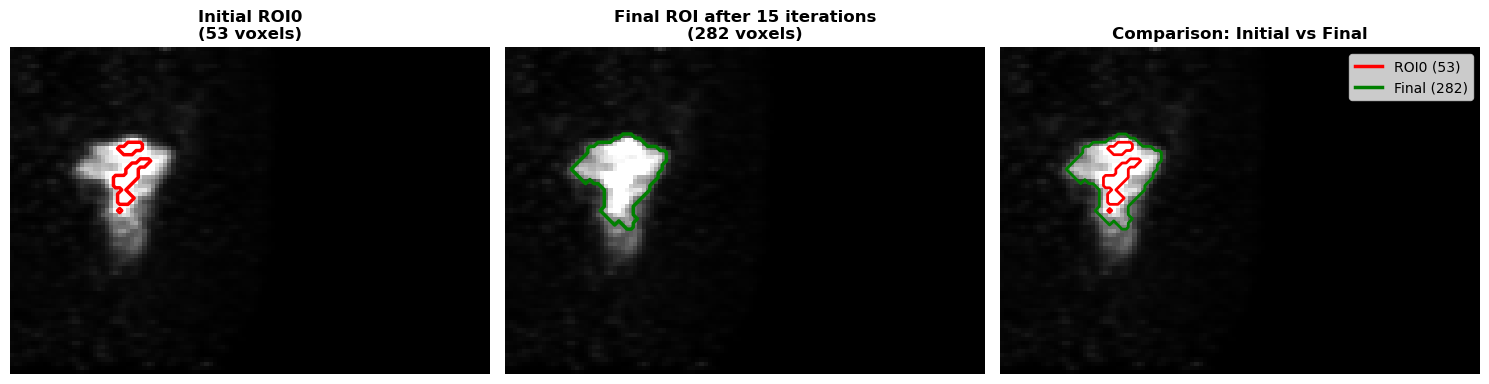

In [12]:
# Visualization: Final ROI evolution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Original image with initial mask
axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].contour(mask0, colors='r', linewidths=2.5)
axes[0].set_title(f"Initial ROI0\n({mask0.sum()} voxels)", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Plot 2: Original image with final ROI
axes[1].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[1].contour(roi_final, colors='g', linewidths=2.5)
axes[1].set_title(f"Final ROI after {NUM_ITERATIONS} iterations\n({roi_final.sum()} voxels)", 
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

# Plot 3: Comparison with overlays
axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='r', linewidths=2, label=f'ROI0 ({mask0.sum()})')
axes[2].contour(roi_final, colors='g', linewidths=2, label=f'Final ({roi_final.sum()})')

# Create custom legend
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='r', lw=2.5),
    Line2D([0], [0], color='g', lw=2.5)
]
axes[2].legend(custom_lines, [f'ROI0 ({mask0.sum()})', f'Final ({roi_final.sum()})'], 
               loc='upper right', fontsize=10)
axes[2].set_title("Comparison: Initial vs Final", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

C:\Users\oscar\AppData\Local\Temp\ipykernel_17744\2916683759.py:9: UserWarning: The following kwargs were not used by contour: 'label'
  axes[0, 0].contour(mask0, colors='r', linewidths=1.5, linestyles='--', label='ROI0')
C:\Users\oscar\AppData\Local\Temp\ipykernel_17744\2916683759.py:10: UserWarning: The following kwargs were not used by contour: 'label'
  axes[0, 0].contour(data_iter["roi_current"], colors='b', linewidths=2, label='Current ROI')
C:\Users\oscar\AppData\Local\Temp\ipykernel_17744\2916683759.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(loc='upper right')


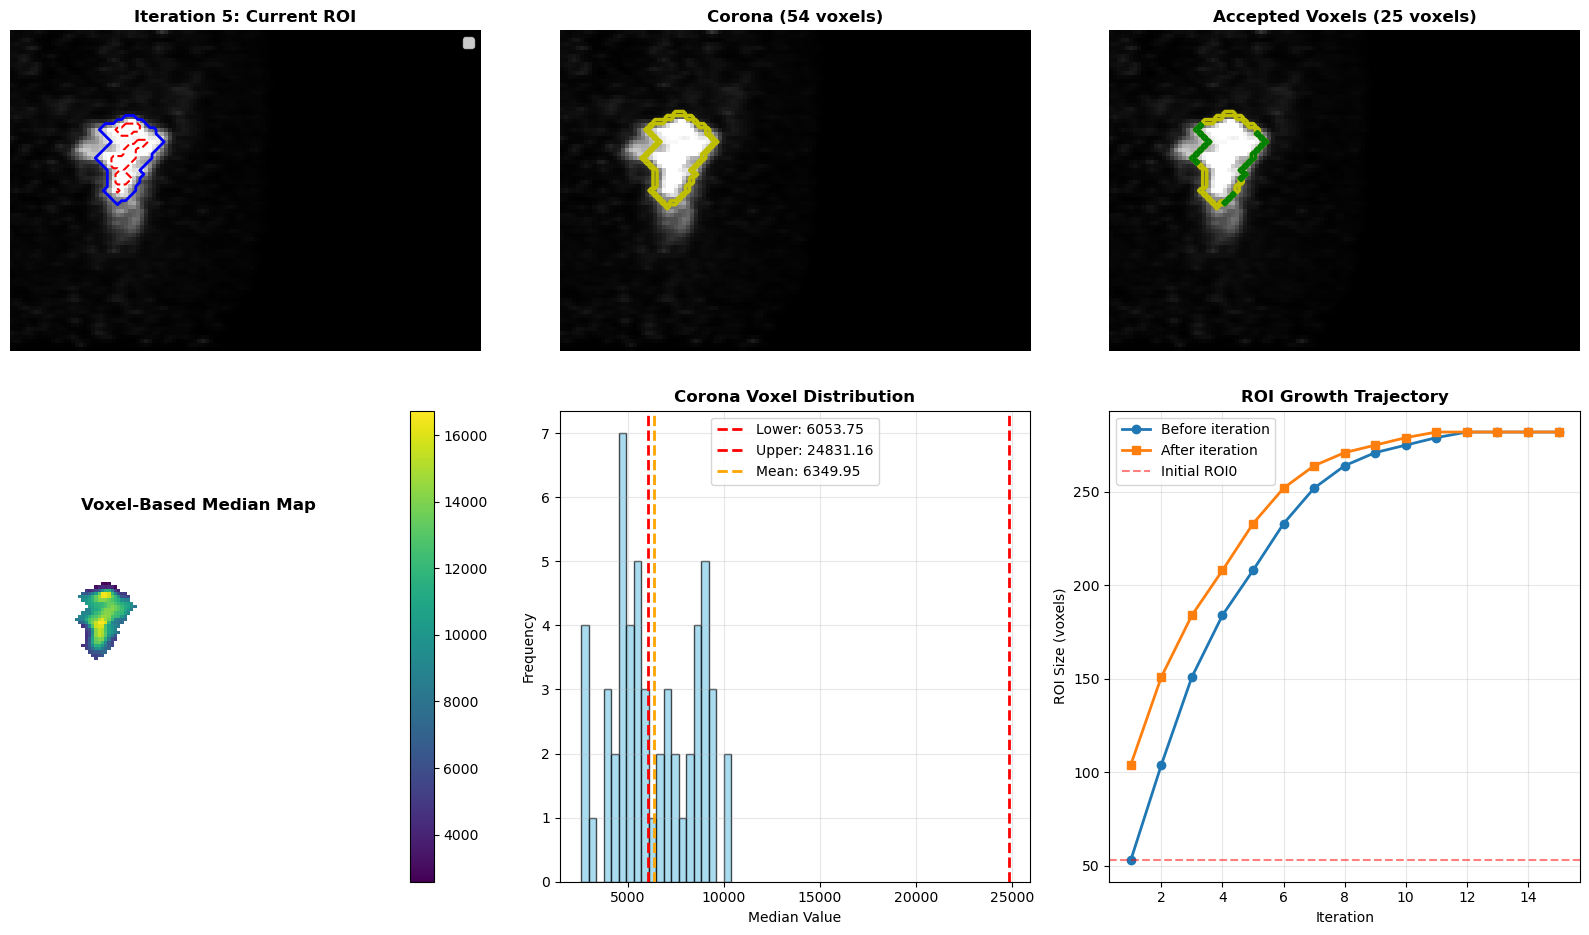

In [13]:
# Detailed visualization of a specific iteration (example: iteration 5)
iter_to_show = min(5, NUM_ITERATIONS)  # Show iteration 5, or last if fewer iterations
data_iter = history[iter_to_show - 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Iteration details
axes[0, 0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 0].contour(mask0, colors='r', linewidths=1.5, linestyles='--', label='ROI0')
axes[0, 0].contour(data_iter["roi_current"], colors='b', linewidths=2, label='Current ROI')
axes[0, 0].set_title(f"Iteration {iter_to_show}: Current ROI", fontweight='bold')
axes[0, 0].legend(loc='upper right')
axes[0, 0].axis('off')

axes[0, 1].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 1].contour(data_iter["corona"], colors='y', linewidths=2.5)
axes[0, 1].set_title(f"Corona ({data_iter['corona'].sum()} voxels)", fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 2].contour(data_iter["corona"], colors='y', linewidths=2.5)
axes[0, 2].contour(data_iter["mask_accepted"], colors='g', linewidths=2.5)
axes[0, 2].set_title(f"Accepted Voxels ({data_iter['mask_accepted'].sum()} voxels)", fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Radiomic map and statistics
voxel_map = data_iter["voxel_map"]
voxel_map_masked = np.copy(voxel_map)
voxel_map_masked[voxel_map == 0] = np.nan

im = axes[1, 0].imshow(voxel_map_masked, cmap="viridis")
axes[1, 0].set_title("Voxel-Based Median Map", fontweight='bold')
plt.colorbar(im, ax=axes[1, 0])
axes[1, 0].axis('off')

corona_vals = data_iter["corona_values"]
axes[1, 1].hist(corona_vals[corona_vals > 0], bins=20, edgecolor='k', alpha=0.7, color='skyblue')
axes[1, 1].axvline(lower_limit, color='r', linestyle='--', linewidth=2, label=f'Lower: {lower_limit:.2f}')
axes[1, 1].axvline(upper_limit, color='r', linestyle='--', linewidth=2, label=f'Upper: {upper_limit:.2f}')
axes[1, 1].axvline(corona_vals[corona_vals > 0].mean(), color='orange', linestyle='--', 
                   linewidth=2, label=f'Mean: {corona_vals[corona_vals > 0].mean():.2f}')
axes[1, 1].set_xlabel("Median Value")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Corona Voxel Distribution", fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Growth trajectory
iter_range = [r["Iteration"] for r in results]
roi_sizes = [r["Current ROI Size"] for r in results]
new_sizes = [r["New ROI Size"] for r in results]

axes[1, 2].plot(iter_range, roi_sizes, 'o-', linewidth=2, markersize=6, label='Before iteration')
axes[1, 2].plot(iter_range, new_sizes, 's-', linewidth=2, markersize=6, label='After iteration')
axes[1, 2].axhline(mask0.sum(), color='r', linestyle='--', alpha=0.5, label='Initial ROI0')
axes[1, 2].set_xlabel("Iteration")
axes[1, 2].set_ylabel("ROI Size (voxels)")
axes[1, 2].set_title("ROI Growth Trajectory", fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Stage 7: Comparison with manual segmentation

In [14]:
# ==============================================================================
# Stage 7.1: Basic Overlap Analysis
# ==============================================================================

manual = manual_mask_roi.astype(bool)
auto = roi_final.astype(bool)

TP = np.logical_and(manual, auto).sum()
FP = np.logical_and(~manual, auto).sum()
FN = np.logical_and(manual, ~auto).sum()
TN = np.logical_and(~manual, ~auto).sum()

print("="*60)
print("OVERLAP ANALYSIS")
print("="*60)

print(f"Manual voxels:     {manual.sum()}")
print(f"Automatic voxels:  {auto.sum()}")

print()
print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"TN: {TN}")

OVERLAP ANALYSIS
Manual voxels:     318
Automatic voxels:  282

TP: 278
FP: 4
FN: 40
TN: 8842


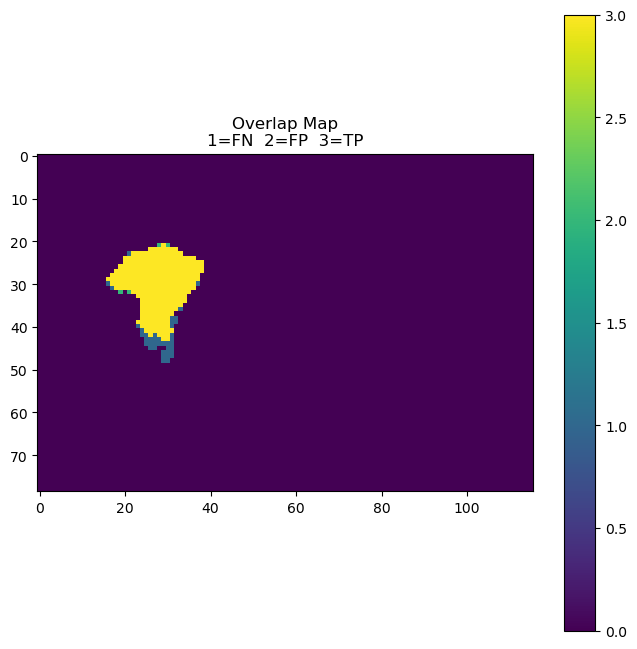

In [15]:
# ==============================================================================
# Visual overlap map
# ==============================================================================

overlap = np.zeros_like(manual, dtype=np.uint8)

overlap[manual & auto] = 3      # TP
overlap[~manual & auto] = 2     # FP
overlap[manual & ~auto] = 1     # FN

plt.figure(figsize=(8,8))

plt.imshow(overlap)

plt.title(
    "Overlap Map\n"
    "1=FN  2=FP  3=TP"
)

plt.colorbar()
plt.show()

C:\Users\oscar\AppData\Local\Temp\ipykernel_17744\829081298.py:10: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(
C:\Users\oscar\AppData\Local\Temp\ipykernel_17744\829081298.py:17: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(


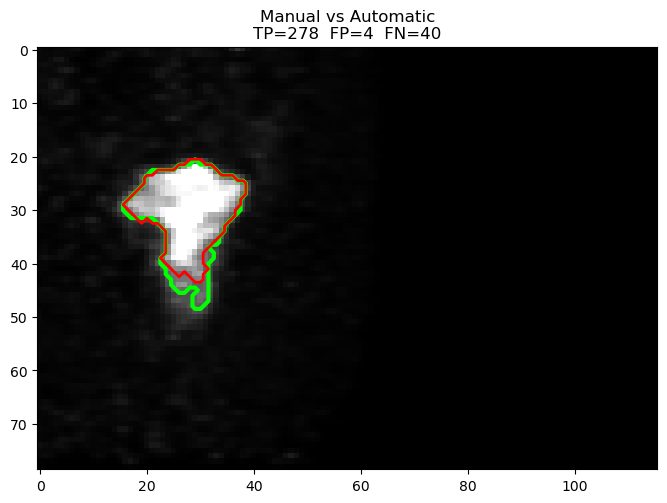

In [16]:
plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

plt.contour(
    manual,
    colors="lime",
    linewidths=3,
    label="Manual"
)

plt.contour(
    auto,
    colors="red",
    linewidths=2,
    label="Automatic"
)

plt.title(
    f"Manual vs Automatic\n"
    f"TP={TP}  FP={FP}  FN={FN}"
)

plt.show()

In [17]:

dice = (2 * TP) / (2 * TP + FP + FN)

iou = TP / (TP + FP + FN)

recall = TP / (TP + FN)

precision = TP / (TP + FP)

metrics_df = pd.DataFrame({
    "Metric": [
        "Dice",
        "IoU",
        "Recall",
        "Precision"
    ],
    "Value": [
        dice,
        iou,
        recall,
        precision
    ]
})

metrics_df

,Metric,Value
0,Dice,0.926667
1,IoU,0.863354
2,Recall,0.874214
3,Precision,0.985816


## Stage 8: Comparative Evaluation of Acceptance Strategies

This section evaluates alternative voxel acceptance rules for multiple PyRadiomics features, using the manual segmentation (`manual_mask_roi`) as reference. The goal is to compare different statistically justified strategies and identify the best feature/strategy combination.

In [18]:
# Prepare fixed inputs for evaluation
manual = manual_mask_roi.astype(bool)
img_3d = roi_img[np.newaxis, :, :].astype(np.float32)
sitk_img = sitk.GetImageFromArray(img_3d)
mask0_3d = mask0[np.newaxis, :, :].astype(np.uint8)
sitk_mask0 = sitk.GetImageFromArray(mask0_3d)

FEATURES = [
    ('firstorder', 'Median'),
    ('firstorder', 'Skewness'),
    ('firstorder', 'Energy'),
    ('firstorder', 'TotalEnergy'),
    ('glcm', 'Contrast'),
    ('glcm', 'Idmn'),
    #('glcm', 'Dissimilarity'),
    ('ngtdm', 'Coarseness'),
    ('ngtdm', 'Busyness'),
    ('ngtdm', 'Complexity')
]

# Define candidate acceptance strategies
ROBUST_K = 3
PERCENTILE_LOW, PERCENTILE_HIGH = 5, 95
KDE_CUTOFF_PERCENTILE = 10

def create_extractor(feature_class, feature_name):
    extractor = featureextractor.RadiomicsFeatureExtractor()
    extractor.disableAllFeatures()
    extractor.enableFeaturesByName(**{feature_class: [feature_name]})
    return extractor

def feature_key(feature_class, feature_name):
    return f'original_{feature_class}_{feature_name}'

def compute_hdi_interval(kde, values, mass=0.90, grid_size=1500):
    if kde is None or len(values) == 0:
        return None, None
    grid = np.linspace(np.min(values), np.max(values), grid_size)
    densities = kde(grid)
    dx = grid[1] - grid[0]
    probability = densities * dx
    total = probability.sum()
    if total <= 0:
        return None, None
    cumulative = np.cumsum(probability)
    target_mass = mass * total
    best_width = np.inf
    best_low = None
    best_high = None
    j = 0
    for i in range(grid_size):
        while j < grid_size and cumulative[j] < cumulative[i] + target_mass:
            j += 1
        if j >= grid_size:
            break
        width = grid[j] - grid[i]
        if width < best_width:
            best_width = width
            best_low = grid[i]
            best_high = grid[j]
    return best_low, best_high

def compute_reference_stats(values):
    values = np.asarray(values, dtype=float)
    median = np.median(values)
    mad = np.median(np.abs(values - median))
    mad_scaled = mad * 1.4826
    q05 = np.percentile(values, PERCENTILE_LOW)
    q95 = np.percentile(values, PERCENTILE_HIGH)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1
    mean = values.mean()
    std = values.std()
    density_cutoff = None
    kde = None
    kde_hdi_low = None
    kde_hdi_high = None
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(values)
        densities = kde(values)
        if densities.size > 0:
            density_cutoff = np.percentile(densities, KDE_CUTOFF_PERCENTILE)
            kde_hdi_low, kde_hdi_high = compute_hdi_interval(kde, values, mass=0.90)
    except Exception:
        kde = None
    return {
        'mean': mean,
        'std': std,
        'median': median,
        'mad_scaled': mad_scaled,
        'q05': q05,
        'q95': q95,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'tukey_low': q1 - 1.5 * iqr,
        'tukey_high': q3 + 1.5 * iqr,
        'kde': kde,
        'density_cutoff': density_cutoff,
        'kde_hdi_low': kde_hdi_low,
        'kde_hdi_high': kde_hdi_high
    }

def acceptance_mean_std(values, stats):
    values = np.asarray(values, dtype=float)
    return np.abs(values - stats['mean']) <= K_VALUE * max(stats['std'], 1e-8)

def acceptance_median_mad(values, stats):
    values = np.asarray(values, dtype=float)
    if stats['mad_scaled'] <= 0:
        return np.abs(values - stats['median']) <= ROBUST_K * max(stats['std'], 1e-8)
    return np.abs(values - stats['median']) <= ROBUST_K * stats['mad_scaled']

def acceptance_percentile(values, stats):
    values = np.asarray(values, dtype=float)
    return (values >= stats['q05']) & (values <= stats['q95'])

def acceptance_tukey(values, stats):
    values = np.asarray(values, dtype=float)
    return (values >= stats['tukey_low']) & (values <= stats['tukey_high'])

def acceptance_kde(values, stats):
    values = np.asarray(values, dtype=float)
    if stats['kde'] is None or stats['density_cutoff'] is None:
        return np.zeros(values.shape, dtype=bool)
    densities = stats['kde'](values)
    return densities >= stats['density_cutoff']

def acceptance_kde_hdi(values, stats):
    values = np.asarray(values, dtype=float)
    if stats['kde_hdi_low'] is None or stats['kde_hdi_high'] is None:
        return np.zeros(values.shape, dtype=bool)
    return (values >= stats['kde_hdi_low']) & (values <= stats['kde_hdi_high'])

ACCEPTANCE_STRATEGIES = [
    ('Mean ± K*Std', acceptance_mean_std),
    ('Median ± 3*MAD', acceptance_median_mad),
    ('5-95 Percentiles', acceptance_percentile),
    ('Tukey fences (1.5 IQR)', acceptance_tukey),
    ('KDE density cutoff', acceptance_kde),
    ('KDE HDI (90%)', acceptance_kde_hdi)
]

def compute_feature_map(extractor, feature_key, sitk_mask):
    result = extractor.execute(sitk_img, sitk_mask, voxelBased=True)
    full_map, _ = reconstruct_voxel_map(result, roi_img.shape, feature_key)
    return full_map

def compute_metrics(manual_mask, auto_mask):
    tp = np.logical_and(manual_mask, auto_mask).sum()
    fp = np.logical_and(~manual_mask, auto_mask).sum()
    fn = np.logical_and(manual_mask, ~auto_mask).sum()
    dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    return {
        'Dice': dice,
        'IoU': iou,
        'Recall': recall,
        'Precision': precision,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'Final Size': auto_mask.sum()
    }

results = []

for feature_class, feature_name in FEATURES:
    extractor = create_extractor(feature_class, feature_name)
    feature_key_name = feature_key(feature_class, feature_name)

    try:
        voxel_map_roi0 = compute_feature_map(extractor, feature_key_name, sitk_mask0)
        vals_roi0 = voxel_map_roi0[mask0]
        if len(vals_roi0) == 0:
            raise ValueError('ROI0 reference contains no voxels for feature')
        ref_stats = compute_reference_stats(vals_roi0)

        for strategy_name, strategy_fn in ACCEPTANCE_STRATEGIES:
            roi_current = mask0.copy()
            for _ in range(NUM_ITERATIONS):
                roi_dilated = binary_dilation(roi_current)
                corona = roi_dilated & (~roi_current)
                if not corona.any():
                    break
                sitk_mask = sitk.GetImageFromArray(roi_dilated.astype(np.uint8)[np.newaxis, :, :])
                full_map = compute_feature_map(extractor, feature_key_name, sitk_mask)
                corona_values = full_map[corona]
                accepted = strategy_fn(corona_values, ref_stats)
                mask_accepted = np.zeros_like(roi_current, dtype=bool)
                mask_accepted[corona] = accepted
                roi_current = roi_current | mask_accepted

            metrics = compute_metrics(manual, roi_current)
            results.append({
                'Feature': f'{feature_class}.{feature_name}',
                'Strategy': strategy_name,
                **metrics
            })
            print(
    f"Evaluated {feature_class}.{feature_name} + {strategy_name}: "
    f"Dice={metrics['Dice']:.4f}, IoU={metrics['IoU']:.4f}, "
    f"Recall={metrics['Recall']:.4f}, Precision={metrics['Precision']:.4f}"
)

    except Exception as error:
        print(f'Skipping feature {feature_class}.{feature_name}: {error}')
        continue

summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(by=['Dice', 'IoU'], ascending=False).reset_index(drop=True)


Evaluated firstorder.Median + Mean ± K*Std: Dice=0.9267, IoU=0.8634, Recall=0.8742, Precision=0.9858
Evaluated firstorder.Median + Median ± 3*MAD: Dice=0.5772, IoU=0.4057, Recall=0.4057, Precision=1.0000
Evaluated firstorder.Median + 5-95 Percentiles: Dice=0.3085, IoU=0.1824, Recall=0.1824, Precision=1.0000
Evaluated firstorder.Median + Tukey fences (1.5 IQR): Dice=0.5140, IoU=0.3459, Recall=0.3459, Precision=1.0000
Evaluated firstorder.Median + KDE density cutoff: Dice=0.3085, IoU=0.1824, Recall=0.1824, Precision=1.0000
Evaluated firstorder.Median + KDE HDI (90%): Dice=0.3130, IoU=0.1855, Recall=0.1855, Precision=1.0000
Evaluated firstorder.Skewness + Mean ± K*Std: Dice=0.4520, IoU=0.2920, Recall=1.0000, Precision=0.2920
Evaluated firstorder.Skewness + Median ± 3*MAD: Dice=0.4525, IoU=0.2924, Recall=0.9969, Precision=0.2927
Evaluated firstorder.Skewness + 5-95 Percentiles: Dice=0.4946, IoU=0.3286, Recall=0.8711, Precision=0.3454
Evaluated firstorder.Skewness + Tukey fences (1.5 IQR): 

c:\Users\oscar\anaconda3\envs\Thesisradiomics\lib\site-packages\radiomics\glcm.py:344: RuntimeWarning: Mean of empty slice
  return numpy.nanmean(cont, 1)


Evaluated glcm.Contrast + Mean ± K*Std: Dice=0.2857, IoU=0.1667, Recall=0.1667, Precision=1.0000
Evaluated glcm.Contrast + Median ± 3*MAD: Dice=0.2857, IoU=0.1667, Recall=0.1667, Precision=1.0000
Evaluated glcm.Contrast + 5-95 Percentiles: Dice=0.2857, IoU=0.1667, Recall=0.1667, Precision=1.0000
Evaluated glcm.Contrast + Tukey fences (1.5 IQR): Dice=0.2857, IoU=0.1667, Recall=0.1667, Precision=1.0000
Evaluated glcm.Contrast + KDE density cutoff: Dice=0.2857, IoU=0.1667, Recall=0.1667, Precision=1.0000
Evaluated glcm.Contrast + KDE HDI (90%): Dice=0.2857, IoU=0.1667, Recall=0.1667, Precision=1.0000


c:\Users\oscar\anaconda3\envs\Thesisradiomics\lib\site-packages\radiomics\glcm.py:676: RuntimeWarning: Mean of empty slice
  return numpy.nanmean(idmn, 1)


Evaluated glcm.Idmn + Mean ± K*Std: Dice=0.2857, IoU=0.1667, Recall=0.1667, Precision=1.0000
Evaluated glcm.Idmn + Median ± 3*MAD: Dice=0.2857, IoU=0.1667, Recall=0.1667, Precision=1.0000
Evaluated glcm.Idmn + 5-95 Percentiles: Dice=0.2857, IoU=0.1667, Recall=0.1667, Precision=1.0000
Evaluated glcm.Idmn + Tukey fences (1.5 IQR): Dice=0.2857, IoU=0.1667, Recall=0.1667, Precision=1.0000
Evaluated glcm.Idmn + KDE density cutoff: Dice=0.2857, IoU=0.1667, Recall=0.1667, Precision=1.0000
Evaluated glcm.Idmn + KDE HDI (90%): Dice=0.2857, IoU=0.1667, Recall=0.1667, Precision=1.0000
Evaluated ngtdm.Coarseness + Mean ± K*Std: Dice=0.4520, IoU=0.2920, Recall=1.0000, Precision=0.2920
Evaluated ngtdm.Coarseness + Median ± 3*MAD: Dice=0.7665, IoU=0.6214, Recall=0.8931, Precision=0.6714
Evaluated ngtdm.Coarseness + 5-95 Percentiles: Dice=0.7222, IoU=0.5652, Recall=0.9403, Precision=0.5863
Evaluated ngtdm.Coarseness + Tukey fences (1.5 IQR): Dice=0.7620, IoU=0.6155, Recall=0.9465, Precision=0.6377
Eva

| Ranking | Característica radiomica   | Método estadístico         |       Dice |        IoU |     Recall |  Precision |
| ------: | -------------------------- | -------------------------- | ---------: | ---------: | ---------: | ---------: |
|   **1** | **NGTDM.Coarseness**       | **Median ± 3·MAD**         | **0.7665** | **0.6214** |     0.8931 |     0.6714 |
|   **2** | **NGTDM.Coarseness**       | **Tukey fences (1.5 IQR)** | **0.7620** | **0.6155** |     0.9465 |     0.6377 |
|   **3** | **NGTDM.Coarseness**       | **KDE density cutoff**     | **0.7422** | **0.5901** | **0.9780** |     0.5981 |
|   **4** | **NGTDM.Coarseness**       | **5–95 Percentiles**       | **0.7222** | **0.5652** |     0.9403 |     0.5863 |
|   **5** | **NGTDM.Complexity**       | **5–95 Percentiles**       | **0.6574** | **0.4896** |     0.8176 |     0.5497 |
|   **6** | **FirstOrder.TotalEnergy** | **KDE HDI (90%)**          | **0.6174** | **0.4465** |     0.4465 | **1.0000** |
|   **7** | **FirstOrder.Energy**      | **KDE HDI (90%)**          | **0.6174** | **0.4465** |     0.4465 | **1.0000** |
|   **8** | **FirstOrder.TotalEnergy** | **KDE density cutoff**     | **0.5929** | **0.4214** |     0.4214 | **1.0000** |
|   **9** | **FirstOrder.Energy**      | **KDE density cutoff**     | **0.5929** | **0.4214** |     0.4214 | **1.0000** |
|  **10** | **FirstOrder.TotalEnergy** | **5–95 Percentiles**       | **0.5867** | **0.4151** |     0.4151 | **1.0000** |
|  **11** | **FirstOrder.Energy**      | **5–95 Percentiles**       | **0.5867** | **0.4151** |     0.4151 | **1.0000** |
|  **12** | **FirstOrder.Median**      | **Median ± 3·MAD**         | **0.5772** | **0.4057** |     0.4057 | **1.0000** |


### Notes
- The new evaluation keeps the initial intensity threshold fixed and does not optimize it.
- Each strategy uses the ROI0 voxel distribution as the fixed reference.
- The comparison is against the manual binary mask `manual_mask_roi`.

# ==============================================================================
# Stage 9: Radiomic Feature Discriminative Analysis
# ==============================================================================


In [20]:
# ==============================================================================
# Stage 9: Evaluate All PyRadiomics Voxel-Based Features
# ==============================================================================

from radiomics import getFeatureClasses

FEATURES = []

feature_classes = getFeatureClasses()

for class_name, feature_class in feature_classes.items():

    # Shape features are not voxel-based
    if class_name == "shape":
        continue

    for feature_name in feature_class.getFeatureNames().keys():

        FEATURES.append((class_name, feature_name))

print(f"Total features: {len(FEATURES)}")

Total features: 110


In [ ]:
import warnings

FEATURES = []

for class_name, feature_class in feature_classes.items():

    if class_name == "shape":
        continue

    for feature_name in feature_class.getFeatureNames():

        extractor = featureextractor.RadiomicsFeatureExtractor()
        extractor.disableAllFeatures()
        extractor.enableFeaturesByName(**{class_name: [feature_name]})

        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")

            try:
                extractor.execute(
                    sitk_img,
                    sitk_mask0,
                    voxelBased=True
                )

                deprecated = any(
                    "deprecated" in str(warn.message).lower()
                    for warn in w
                )

                if deprecated:
                    print(f"⚠ {class_name}.{feature_name} (deprecated)")
                    continue

                FEATURES.append((class_name, feature_name))
                print(f"✓ {class_name}.{feature_name}")

            except Exception:
                print(f"✗ {class_name}.{feature_name}")

In [ ]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import SimpleITK as sitk
from scipy.ndimage import binary_dilation
from scipy.stats import ks_2samp, wasserstein_distance
from radiomics import featureextractor

sns.set_theme(style="whitegrid", context="notebook")

stage9_output_dir = Path("results") / "stage9_radiomic_feature_analysis"
stage9_output_dir.mkdir(parents=True, exist_ok=True)

roi_labels = [f"ROI{i}" for i in range(5)]
corona_labels = [f"Corona{i}" for i in range(1, 5)]
all_region_labels = roi_labels + corona_labels

if "manual_mask_roi" not in globals():
    raise RuntimeError("manual_mask_roi is required for Stage 9")
if "sitk_img" not in globals():
    raise RuntimeError("sitk_img is required for Stage 9")
if "reconstruct_voxel_map" not in globals():
    raise RuntimeError("reconstruct_voxel_map is required for Stage 9")
if "FEATURES" not in globals() or not FEATURES:
    raise RuntimeError("FEATURES is required for Stage 9")


def normalize_feature_entry(entry):
    if isinstance(entry, dict):
        feature_class = entry.get("feature_class") or entry.get("class") or entry.get("FeatureClass")
        feature_name = entry.get("feature_name") or entry.get("name") or entry.get("FeatureName")
        if feature_class is None or feature_name is None:
            return None
        return str(feature_class), str(feature_name)
    if isinstance(entry, (list, tuple)) and len(entry) >= 2:
        return str(entry[0]), str(entry[1])
    return None


def build_cumulative_regions(mask_2d):
    mask_2d = np.asarray(mask_2d).astype(bool)
    roi_masks = [mask_2d]
    for dilation_iteration in range(1, 5):
        roi_masks.append(binary_dilation(mask_2d, iterations=dilation_iteration))
    corona_masks = [np.logical_and(roi_masks[index], np.logical_not(roi_masks[0])) for index in range(1, 5)]
    return roi_masks, corona_masks


def region_values_from_map(voxel_map_2d, region_mask_2d):
    values = np.asarray(voxel_map_2d[region_mask_2d], dtype=float).ravel()
    values = values[np.isfinite(values)]
    return values


def compute_region_statistics(values):
    values = np.asarray(values, dtype=float).ravel()
    values = values[np.isfinite(values)]

    if values.size == 0:
        return {
            "NumberOfVoxels": 0,
            "Mean": np.nan,
            "Median": np.nan,
            "Variance": np.nan,
            "StandardDeviation": np.nan,
            "CoefficientOfVariation": np.nan,
            "MAD": np.nan,
            "IQR": np.nan,
            "Minimum": np.nan,
            "Maximum": np.nan,
            "P05": np.nan,
            "P95": np.nan,
        }

    mean_value = float(np.mean(values))
    median_value = float(np.median(values))
    variance_value = float(np.var(values, ddof=1)) if values.size > 1 else 0.0
    std_value = float(np.std(values, ddof=1)) if values.size > 1 else 0.0
    coefficient_of_variation = float(std_value / abs(mean_value)) if abs(mean_value) > 0 else np.nan
    mad_value = float(np.median(np.abs(values - median_value)))
    p25, p75 = np.percentile(values, [25, 75])
    iqr_value = float(p75 - p25)

    return {
        "NumberOfVoxels": int(values.size),
        "Mean": mean_value,
        "Median": median_value,
        "Variance": variance_value,
        "StandardDeviation": std_value,
        "CoefficientOfVariation": coefficient_of_variation,
        "MAD": mad_value,
        "IQR": iqr_value,
        "Minimum": float(np.min(values)),
        "Maximum": float(np.max(values)),
        "P05": float(np.percentile(values, 5)),
        "P95": float(np.percentile(values, 95)),
    }


def compute_pair_metrics(reference_values, comparison_values):
    reference_values = np.asarray(reference_values, dtype=float).ravel()
    comparison_values = np.asarray(comparison_values, dtype=float).ravel()
    reference_values = reference_values[np.isfinite(reference_values)]
    comparison_values = comparison_values[np.isfinite(comparison_values)]

    if reference_values.size == 0 or comparison_values.size == 0:
        return {
            "CohensD": np.nan,
            "FisherScore": np.nan,
            "WassersteinDistance": np.nan,
            "BhattacharyyaDistance": np.nan,
            "HistogramOverlapCoefficient": np.nan,
            "KSStatistic": np.nan,
        }

    mean_reference = float(np.mean(reference_values))
    mean_comparison = float(np.mean(comparison_values))
    std_reference = float(np.std(reference_values, ddof=1)) if reference_values.size > 1 else 0.0
    std_comparison = float(np.std(comparison_values, ddof=1)) if comparison_values.size > 1 else 0.0

    pooled_denom = max(reference_values.size + comparison_values.size - 2, 1)
    pooled_variance = (
        ((reference_values.size - 1) * std_reference ** 2)
        + ((comparison_values.size - 1) * std_comparison ** 2)
    ) / pooled_denom
    pooled_std = math.sqrt(pooled_variance) if pooled_variance > 0 else 0.0
    cohens_d = (mean_reference - mean_comparison) / pooled_std if pooled_std > 0 else 0.0
    fisher_score = (mean_reference - mean_comparison) ** 2 / (std_reference ** 2 + std_comparison ** 2 + 1e-12)
    wasserstein = float(wasserstein_distance(reference_values, comparison_values))

    combined_values = np.concatenate([reference_values, comparison_values])
    if np.allclose(np.min(combined_values), np.max(combined_values)):
        bhattacharyya_distance = 0.0
        histogram_overlap = 1.0
    else:
        bin_edges = np.histogram_bin_edges(combined_values, bins="fd")
        if bin_edges.size < 3:
            bin_edges = np.linspace(np.min(combined_values), np.max(combined_values), 11)
        hist_reference, _ = np.histogram(reference_values, bins=bin_edges, density=True)
        hist_comparison, _ = np.histogram(comparison_values, bins=bin_edges, density=True)
        bin_widths = np.diff(bin_edges)
        overlap = np.sum(np.minimum(hist_reference, hist_comparison) * bin_widths)
        overlap = float(np.clip(overlap, 0.0, 1.0))
        bc = np.sum(np.sqrt(hist_reference * hist_comparison) * bin_widths)
        bc = float(np.clip(bc, 1e-12, 1.0))
        bhattacharyya_distance = float(-np.log(bc))
        histogram_overlap = overlap

    ks_statistic = float(ks_2samp(reference_values, comparison_values).statistic)

    return {
        "CohensD": float(cohens_d),
        "FisherScore": float(fisher_score),
        "WassersteinDistance": wasserstein,
        "BhattacharyyaDistance": bhattacharyya_distance,
        "HistogramOverlapCoefficient": histogram_overlap,
        "KSStatistic": ks_statistic,
    }


def create_feature_extractor(feature_class, feature_name):
    extractor = featureextractor.RadiomicsFeatureExtractor()
    extractor.disableAllFeatures()
    extractor.enableFeaturesByName(**{feature_class: [feature_name]})
    return extractor


def resolve_feature_key(result_dict, feature_class, feature_name):
    direct_key = f"original_{feature_class}_{feature_name}"
    if direct_key in result_dict:
        return direct_key
    suffix = f"_{feature_name}"
    candidate_keys = [key for key in result_dict.keys() if key.startswith("original_") and key.endswith(suffix)]
    if candidate_keys:
        return candidate_keys[0]
    candidate_keys = [key for key in result_dict.keys() if key.startswith("original_")]
    if candidate_keys:
        return candidate_keys[0]
    raise KeyError(f"Could not resolve voxel map key for {feature_class}.{feature_name}")


def add_rank_scores(summary_df, metric_columns, higher_is_better=True):
    score_columns = []
    for metric_column in metric_columns:
        rank_values = summary_df[metric_column].rank(pct=True, ascending=True)
        if higher_is_better:
            score = rank_values
        else:
            score = 1.0 - rank_values
        score_column = f"{metric_column}_Score"
        summary_df[score_column] = score.fillna(0.0)
        score_columns.append(score_column)
    return summary_df, score_columns


roi_masks_2d, corona_masks_2d = build_cumulative_regions(np.asarray(manual_mask_roi).astype(bool))
roi_values_by_region = {}
corona_values_by_region = {}

stage9_cross_stats_records = []
stage9_canonical_stats_records = []
stage9_comparison_records = []
stage9_feature_summary_records = []
stage9_supported_features = []
stage9_skipped_features = []

feature_entries = []
for feature_entry in FEATURES:
    normalized_entry = normalize_feature_entry(feature_entry)
    if normalized_entry is None:
        continue
    if normalized_entry not in feature_entries:
        feature_entries.append(normalized_entry)

if not feature_entries:
    raise RuntimeError("No valid feature entries were found in FEATURES")

for feature_class, feature_name in feature_entries:
    feature_label = f"{feature_class}.{feature_name}"
    feature_slug = f"{feature_class}_{feature_name}".replace(" ", "_").replace("/", "_")

    try:
        extractor = create_feature_extractor(feature_class, feature_name)
        map_region_samples = {}

        for map_index, roi_mask_2d in enumerate(roi_masks_2d):
            map_label = roi_labels[map_index]
            mask_3d = sitk.GetImageFromArray(np.asarray(roi_mask_2d, dtype=np.uint8)[np.newaxis, :, :])
            mask_3d.CopyInformation(sitk_img)

            result = extractor.execute(sitk_img, mask_3d, voxelBased=True)
            feature_key = resolve_feature_key(result, feature_class, feature_name)
            voxel_map_2d, _ = reconstruct_voxel_map(result, np.asarray(manual_mask_roi).shape, feature_key)

            map_region_samples[map_label] = {}
            for region_label, region_mask_2d in zip(roi_labels, roi_masks_2d):
                values = region_values_from_map(voxel_map_2d, region_mask_2d)
                map_region_samples[map_label][region_label] = values
                stage9_cross_stats_records.append({
                    "FeatureClass": feature_class,
                    "FeatureName": feature_name,
                    "Feature": feature_label,
                    "FeatureSlug": feature_slug,
                    "VoxelMap": map_label,
                    "Region": region_label,
                    **compute_region_statistics(values),
                })
            for region_label, region_mask_2d in zip(corona_labels, corona_masks_2d):
                values = region_values_from_map(voxel_map_2d, region_mask_2d)
                map_region_samples[map_label][region_label] = values
                stage9_cross_stats_records.append({
                    "FeatureClass": feature_class,
                    "FeatureName": feature_name,
                    "Feature": feature_label,
                    "FeatureSlug": feature_slug,
                    "VoxelMap": map_label,
                    "Region": region_label,
                    **compute_region_statistics(values),
                })

        canonical_region_samples = {
            "ROI0": map_region_samples["ROI0"]["ROI0"],
            "ROI1": map_region_samples["ROI1"]["ROI1"],
            "ROI2": map_region_samples["ROI2"]["ROI2"],
            "ROI3": map_region_samples["ROI3"]["ROI3"],
            "ROI4": map_region_samples["ROI4"]["ROI4"],
            "Corona1": map_region_samples["ROI1"]["Corona1"],
            "Corona2": map_region_samples["ROI2"]["Corona2"],
            "Corona3": map_region_samples["ROI3"]["Corona3"],
            "Corona4": map_region_samples["ROI4"]["Corona4"],
        }

        for region_label, values in canonical_region_samples.items():
            stage9_canonical_stats_records.append({
                "FeatureClass": feature_class,
                "FeatureName": feature_name,
                "Feature": feature_label,
                "FeatureSlug": feature_slug,
                "Region": region_label,
                "SourceMap": "ROI0" if region_label == "ROI0" else (region_label if region_label.startswith("ROI") else f"ROI{region_label[-1]}"),
                **compute_region_statistics(values),
            })

        roi_evolution_samples = {region_label: canonical_region_samples[region_label] for region_label in roi_labels}
        corona_evolution_samples = {
            "ROI0": canonical_region_samples["ROI0"],
            "Corona1": canonical_region_samples["Corona1"],
            "Corona2": canonical_region_samples["Corona2"],
            "Corona3": canonical_region_samples["Corona3"],
            "Corona4": canonical_region_samples["Corona4"],
        }

        roi_long_df = pd.DataFrame(
            {
                "Region": region_label,
                "Value": value,
            }
            for region_label, values in roi_evolution_samples.items()
            for value in np.asarray(values, dtype=float)
            if np.isfinite(value)
        )
        corona_long_df = pd.DataFrame(
            {
                "Region": region_label,
                "Value": value,
            }
            for region_label, values in corona_evolution_samples.items()
            for value in np.asarray(values, dtype=float)
            if np.isfinite(value)
        )

        region_palette_roi = sns.color_palette("tab10", len(roi_evolution_samples))
        region_palette_corona = sns.color_palette("tab10", len(corona_evolution_samples))

        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        for (region_label, values), color in zip(roi_evolution_samples.items(), region_palette_roi):
            values = np.asarray(values, dtype=float)
            if values.size == 0:
                continue
            axes[0, 0].hist(values, bins=25, density=True, alpha=0.20, color=color, label=region_label)
            if np.unique(values).size > 1:
                sns.kdeplot(values, ax=axes[0, 0], color=color, linewidth=2)
        axes[0, 0].set_title(f"{feature_label} | ROI Evolution | Histograms + KDE")
        axes[0, 0].set_xlabel("Voxel value")
        axes[0, 0].set_ylabel("Density")
        axes[0, 0].legend(fontsize=8, ncol=2)

        sns.boxplot(data=roi_long_df, x="Region", y="Value", ax=axes[0, 1], palette=region_palette_roi, showfliers=False)
        axes[0, 1].set_title(f"{feature_label} | ROI Evolution | Boxplot")
        axes[0, 1].set_xlabel("")
        axes[0, 1].set_ylabel("Voxel value")

        sns.violinplot(data=roi_long_df, x="Region", y="Value", ax=axes[1, 0], palette=region_palette_roi, inner="quartile", cut=0)
        axes[1, 0].set_title(f"{feature_label} | ROI Evolution | Violin Plot")
        axes[1, 0].set_xlabel("")
        axes[1, 0].set_ylabel("Voxel value")

        roi_stats_evolution_rows = []
        for region_label in roi_labels:
            region_stats = compute_region_statistics(roi_evolution_samples[region_label])
            roi_stats_evolution_rows.append({"Region": region_label, **region_stats})
        roi_stats_evolution_df = pd.DataFrame(roi_stats_evolution_rows)
        evolution_metric_map = {
            "Mean": "Mean",
            "Median": "Median",
            "Variance": "Variance",
            "StandardDeviation": "StandardDeviation",
            "MAD": "MAD",
            "CoefficientOfVariation": "CoefficientOfVariation",
            "IQR": "IQR",
        }
        roi_stats_long_df = roi_stats_evolution_df.melt(id_vars="Region", value_vars=list(evolution_metric_map.keys()), var_name="Metric", value_name="Value")
        sns.lineplot(data=roi_stats_long_df, x="Region", y="Value", hue="Metric", marker="o", ax=axes[1, 1])
        axes[1, 1].set_title(f"{feature_label} | ROI Evolution | Statistics")
        axes[1, 1].set_xlabel("")
        axes[1, 1].set_ylabel("Value")
        axes[1, 1].legend(fontsize=8, ncol=2)

        fig.tight_layout()
        fig.savefig(stage9_output_dir / f"{feature_slug}_roi_evolution.png", dpi=220, bbox_inches="tight")
        plt.close(fig)

        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        for (region_label, values), color in zip(corona_evolution_samples.items(), region_palette_corona):
            values = np.asarray(values, dtype=float)
            if values.size == 0:
                continue
            axes[0, 0].hist(values, bins=25, density=True, alpha=0.20, color=color, label=region_label)
            if np.unique(values).size > 1:
                sns.kdeplot(values, ax=axes[0, 0], color=color, linewidth=2)
        axes[0, 0].set_title(f"{feature_label} | Corona Evolution | Histograms + KDE")
        axes[0, 0].set_xlabel("Voxel value")
        axes[0, 0].set_ylabel("Density")
        axes[0, 0].legend(fontsize=8, ncol=2)

        sns.boxplot(data=corona_long_df, x="Region", y="Value", ax=axes[0, 1], palette=region_palette_corona, showfliers=False)
        axes[0, 1].set_title(f"{feature_label} | Corona Evolution | Boxplot")
        axes[0, 1].set_xlabel("")
        axes[0, 1].set_ylabel("Voxel value")

        sns.violinplot(data=corona_long_df, x="Region", y="Value", ax=axes[1, 0], palette=region_palette_corona, inner="quartile", cut=0)
        axes[1, 0].set_title(f"{feature_label} | Corona Evolution | Violin Plot")
        axes[1, 0].set_xlabel("")
        axes[1, 0].set_ylabel("Voxel value")

        corona_stats_evolution_rows = []
        for region_label in ["ROI0", "Corona1", "Corona2", "Corona3", "Corona4"]:
            region_stats = compute_region_statistics(corona_evolution_samples[region_label])
            corona_stats_evolution_rows.append({"Region": region_label, **region_stats})
        corona_stats_evolution_df = pd.DataFrame(corona_stats_evolution_rows)
        corona_stats_long_df = corona_stats_evolution_df.melt(id_vars="Region", value_vars=list(evolution_metric_map.keys()), var_name="Metric", value_name="Value")
        sns.lineplot(data=corona_stats_long_df, x="Region", y="Value", hue="Metric", marker="o", ax=axes[1, 1])
        axes[1, 1].set_title(f"{feature_label} | Corona Evolution | Statistics")
        axes[1, 1].set_xlabel("")
        axes[1, 1].set_ylabel("Value")
        axes[1, 1].legend(fontsize=8, ncol=2)

        fig.tight_layout()
        fig.savefig(stage9_output_dir / f"{feature_slug}_corona_evolution.png", dpi=220, bbox_inches="tight")
        plt.close(fig)

        feature_comparison_rows = []
        for corona_index in range(1, 5):
            corona_label = f"Corona{corona_index}"
            comparison_metrics = compute_pair_metrics(canonical_region_samples["ROI0"], canonical_region_samples[corona_label])
            feature_comparison_rows.append({
                "FeatureClass": feature_class,
                "FeatureName": feature_name,
                "Feature": feature_label,
                "FeatureSlug": feature_slug,
                "Corona": corona_label,
                "CoronaIndex": corona_index,
                **comparison_metrics,
            })
        feature_comparison_df = pd.DataFrame(feature_comparison_rows)
        stage9_comparison_records.extend(feature_comparison_rows)

        roi0_stats = compute_region_statistics(canonical_region_samples["ROI0"])
        roi_canonical_stats = {region_label: compute_region_statistics(canonical_region_samples[region_label]) for region_label in roi_labels}
        corona_canonical_stats = {region_label: compute_region_statistics(canonical_region_samples[region_label]) for region_label in corona_labels}

        stage9_feature_summary_records.append({
            "FeatureClass": feature_class,
            "FeatureName": feature_name,
            "Feature": feature_label,
            "FeatureSlug": feature_slug,
            "ROI0_NumberOfVoxels": roi_canonical_stats["ROI0"]["NumberOfVoxels"] if isinstance(roi_canonical_stats["ROI0"], dict) else roi0_stats["NumberOfVoxels"],
            "ROI0_Mean": roi0_stats["Mean"],
            "ROI0_Median": roi0_stats["Median"],
            "ROI0_Variance": roi0_stats["Variance"],
            "ROI0_StandardDeviation": roi0_stats["StandardDeviation"],
            "ROI0_CoefficientOfVariation": roi0_stats["CoefficientOfVariation"],
            "ROI0_MAD": roi0_stats["MAD"],
            "ROI0_IQR": roi0_stats["IQR"],
            "ROI0_Minimum": roi0_stats["Minimum"],
            "ROI0_Maximum": roi0_stats["Maximum"],
            "ROI0_P05": roi0_stats["P05"],
            "ROI0_P95": roi0_stats["P95"],
            "Corona1_NumberOfVoxels": corona_canonical_stats["Corona1"]["NumberOfVoxels"],
            "Corona2_NumberOfVoxels": corona_canonical_stats["Corona2"]["NumberOfVoxels"],
            "Corona3_NumberOfVoxels": corona_canonical_stats["Corona3"]["NumberOfVoxels"],
            "Corona4_NumberOfVoxels": corona_canonical_stats["Corona4"]["NumberOfVoxels"],
        })

        for corona_index in range(1, 5):
            corona_label = f"Corona{corona_index}"
            comparison_row = feature_comparison_df.loc[feature_comparison_df["Corona"] == corona_label].iloc[0].to_dict()
            stage9_feature_summary_records[-1][f"{corona_label}_CohensD"] = comparison_row["CohensD"]
            stage9_feature_summary_records[-1][f"{corona_label}_FisherScore"] = comparison_row["FisherScore"]
            stage9_feature_summary_records[-1][f"{corona_label}_WassersteinDistance"] = comparison_row["WassersteinDistance"]
            stage9_feature_summary_records[-1][f"{corona_label}_BhattacharyyaDistance"] = comparison_row["BhattacharyyaDistance"]
            stage9_feature_summary_records[-1][f"{corona_label}_HistogramOverlapCoefficient"] = comparison_row["HistogramOverlapCoefficient"]
            stage9_feature_summary_records[-1][f"{corona_label}_KSStatistic"] = comparison_row["KSStatistic"]

        stage9_supported_features.append(feature_label)
        print(f"Processed {feature_label}")

    except Exception as error:
        stage9_skipped_features.append({"FeatureClass": feature_class, "FeatureName": feature_name, "Feature": feature_label, "Error": str(error)})
        print(f"Skipping {feature_label}: {error}")
        continue

stage9_cross_stats_df = pd.DataFrame(stage9_cross_stats_records)
stage9_canonical_stats_df = pd.DataFrame(stage9_canonical_stats_records)
stage9_comparison_df = pd.DataFrame(stage9_comparison_records)
stage9_feature_summary_df = pd.DataFrame(stage9_feature_summary_records)

if stage9_feature_summary_df.empty:
    raise RuntimeError("Stage 9 did not produce any feature summaries")

stage9_comparison_df["CohensDAbs"] = stage9_comparison_df["CohensD"].abs()
stage9_comparison_df["InverseHistogramOverlapCoefficient"] = 1.0 - stage9_comparison_df["HistogramOverlapCoefficient"]

comparison_rank_columns = [
    "CohensDAbs",
    "FisherScore",
    "WassersteinDistance",
    "BhattacharyyaDistance",
    "KSStatistic",
    "InverseHistogramOverlapCoefficient",
]
for metric_column in comparison_rank_columns:
    stage9_comparison_df[f"{metric_column}_Score"] = stage9_comparison_df[metric_column].rank(pct=True, ascending=True).fillna(0.0)

stage9_comparison_df["ComparisonScore"] = stage9_comparison_df[[f"{metric_column}_Score" for metric_column in comparison_rank_columns]].mean(axis=1)

comparison_score_df = stage9_comparison_df.groupby("Feature", as_index=False).agg(
    Corona1_ComparisonScore=("ComparisonScore", lambda values: values.iloc[0]),
    Corona2_ComparisonScore=("ComparisonScore", lambda values: values.iloc[1]),
    Corona3_ComparisonScore=("ComparisonScore", lambda values: values.iloc[2]),
    Corona4_ComparisonScore=("ComparisonScore", lambda values: values.iloc[3]),
    MeanComparisonScore=("ComparisonScore", "mean"),
    ComparisonTrend=("ComparisonScore", lambda values: values.iloc[-1] - values.iloc[0]),
    MonotonicIncreaseRatio=("ComparisonScore", lambda values: float(np.mean(np.diff(values.to_numpy()) > 0)) if len(values) > 1 else np.nan),
    MeanAbsCohensD=("CohensDAbs", "mean"),
    MeanFisherScore=("FisherScore", "mean"),
    MeanWassersteinDistance=("WassersteinDistance", "mean"),
    MeanBhattacharyyaDistance=("BhattacharyyaDistance", "mean"),
    MeanKSStatistic=("KSStatistic", "mean"),
    MeanHistogramOverlapCoefficient=("HistogramOverlapCoefficient", "mean"),
)

summary_df = stage9_feature_summary_df.merge(comparison_score_df, on="Feature", how="left")

roi_stability_metric_columns = [
    "ROI0_CoefficientOfVariation",
    "ROI0_StandardDeviation",
    "ROI0_Variance",
    "ROI0_MAD",
    "ROI0_IQR",
]
for metric_column in roi_stability_metric_columns:
    summary_df[f"{metric_column}_Score"] = 1.0 - summary_df[metric_column].rank(pct=True, ascending=True).fillna(0.0)

summary_df["ROI0_StabilityScore"] = summary_df[[f"{metric_column}_Score" for metric_column in roi_stability_metric_columns]].mean(axis=1)
summary_df["DiscriminationScore"] = (
    0.35 * summary_df["Corona1_ComparisonScore"]
    + 0.30 * summary_df["MeanComparisonScore"]
    + 0.20 * summary_df["ComparisonTrend"].clip(lower=0)
    + 0.15 * summary_df["MonotonicIncreaseRatio"].fillna(0.0)
)

roi_stability_ranking_df = summary_df.sort_values(
    by=["ROI0_StabilityScore", "ROI0_CoefficientOfVariation"],
    ascending=[False, True],
).reset_index(drop=True)
roi_stability_ranking_df.insert(0, "Rank", np.arange(1, len(roi_stability_ranking_df) + 1))
roi_stability_ranking_df = roi_stability_ranking_df[[
    "Rank",
    "FeatureClass",
    "FeatureName",
    "Feature",
    "ROI0_StabilityScore",
    "ROI0_NumberOfVoxels",
    "ROI0_Mean",
    "ROI0_Median",
    "ROI0_Variance",
    "ROI0_StandardDeviation",
    "ROI0_CoefficientOfVariation",
    "ROI0_MAD",
    "ROI0_IQR",
    "ROI0_Minimum",
    "ROI0_Maximum",
    "ROI0_P05",
    "ROI0_P95",
]]

lesion_vs_surrounding_ranking_df = summary_df.sort_values(
    by=["DiscriminationScore", "Corona1_ComparisonScore", "MeanComparisonScore"],
    ascending=[False, False, False],
).reset_index(drop=True)
lesion_vs_surrounding_ranking_df.insert(0, "Rank", np.arange(1, len(lesion_vs_surrounding_ranking_df) + 1))
lesion_vs_surrounding_ranking_df = lesion_vs_surrounding_ranking_df[[
    "Rank",
    "FeatureClass",
    "FeatureName",
    "Feature",
    "DiscriminationScore",
    "Corona1_ComparisonScore",
    "Corona2_ComparisonScore",
    "Corona3_ComparisonScore",
    "Corona4_ComparisonScore",
    "MeanComparisonScore",
    "ComparisonTrend",
    "MonotonicIncreaseRatio",
    "MeanAbsCohensD",
    "MeanFisherScore",
    "MeanWassersteinDistance",
    "MeanBhattacharyyaDistance",
    "MeanKSStatistic",
    "MeanHistogramOverlapCoefficient",
]]

print(f"Stage 9 supported features: {len(stage9_supported_features)}")
print(f"Stage 9 skipped features: {len(stage9_skipped_features)}")
print("ROI Stability Ranking:")
display(roi_stability_ranking_df.head(10))
print("Lesion vs Surrounding Tissue Discrimination Ranking:")
display(lesion_vs_surrounding_ranking_df.head(10))


In [ ]:
#guardamos los df en csv
roi_stability_ranking_df.to_csv(stage9_output_dir / "roi_stability_ranking.csv", index=False)
lesion_vs_surrounding_ranking_df.to_csv(stage9_output_dir / "lesion_vs_surrounding_ranking.csv", index=False)




In [9]:
#cargamos los csv que estan en la carpeta results/stage9_radiomic_feature_analysis
roi_stability_ranking_df = pd.read_csv("results/stage9_radiomic_feature_analysis/roi_stability_ranking.csv")
lesion_vs_surrounding_ranking_df = pd.read_csv("results/stage9_radiomic_feature_analysis/lesion_vs_surrounding_ranking.csv")

In [10]:
features_to_remove = [
    "glcm.Dissimilarity",
    "glcm.Homogeneity1",
    "glcm.Homogeneity2",
    "glcm.SumVariance",
    "gldm.DependencePercentage",
    "gldm.GrayLevelNonUniformityNormalized",
]

roi_df = roi_stability_ranking_df[
    ~roi_stability_ranking_df["Feature"].isin(features_to_remove)
].copy()

disc_df = lesion_vs_surrounding_ranking_df[
    ~lesion_vs_surrounding_ranking_df["Feature"].isin(features_to_remove)
].copy()

In [12]:
combined_df = roi_df[
    [
        "Feature",
        "FeatureClass",
        "FeatureName",
        "ROI0_StabilityScore"
    ]
].merge(
    disc_df[
        [
            "Feature",
            "DiscriminationScore",
            "Corona1_ComparisonScore",
            "MeanComparisonScore",
            "ComparisonTrend",
            "MonotonicIncreaseRatio",
        ]
    ],
    on="Feature"
)
combined_df["GlobalScore"] = (
    0.5 * combined_df["ROI0_StabilityScore"] +
    0.5 * combined_df["DiscriminationScore"]
)

combined_df = combined_df.sort_values(
    "GlobalScore",
    ascending=False
).reset_index(drop=True)

combined_df.insert(0, "Rank", np.arange(1, len(combined_df)+1))

combined_df.head(20)

,Rank,Feature,FeatureClass,FeatureName,ROI0_StabilityScore,DiscriminationScore,Corona1_ComparisonScore,MeanComparisonScore,ComparisonTrend,MonotonicIncreaseRatio,GlobalScore
0,1,glcm.Imc2,glcm,Imc2,0.809710,0.448622,0.743266,0.461595,-0.407828,0.333333,0.629166
1,2,glcm.Idmn,glcm,Idmn,0.724210,0.503483,0.253788,0.559238,0.484428,1.000000,0.613846
2,3,ngtdm.Coarseness,ngtdm,Coarseness,0.678983,0.495381,0.336700,0.509575,0.373316,1.000000,0.587182
3,4,glrlm.ShortRunEmphasis,glrlm,ShortRunEmphasis,0.906940,0.266756,0.228535,0.212910,0.114478,0.666667,0.586848
4,5,glrlm.RunPercentage,glrlm,RunPercentage,0.896709,0.267393,0.232744,0.213489,0.109428,0.666667,0.582051
5,6,glcm.Imc1,glcm,Imc1,0.689606,0.472117,0.781987,0.494739,-0.377525,0.333333,0.580861
6,7,glrlm.RunLengthNonUniformityNormalized,glrlm,RunLengthNonUniformityNormalized,0.884327,0.272996,0.242424,0.222275,0.107323,0.666667,0.578661
7,8,glszm.SmallAreaEmphasis,glszm,SmallAreaEmphasis,0.871945,0.282513,0.250000,0.236742,0.119949,0.666667,0.577229
8,9,glrlm.LongRunEmphasis,glrlm,LongRunEmphasis,0.870055,0.282534,0.250421,0.235480,0.121212,0.666667,0.576295
9,10,glszm.ZonePercentage,glszm,ZonePercentage,0.853633,0.283638,0.258418,0.236848,0.110690,0.666667,0.568636


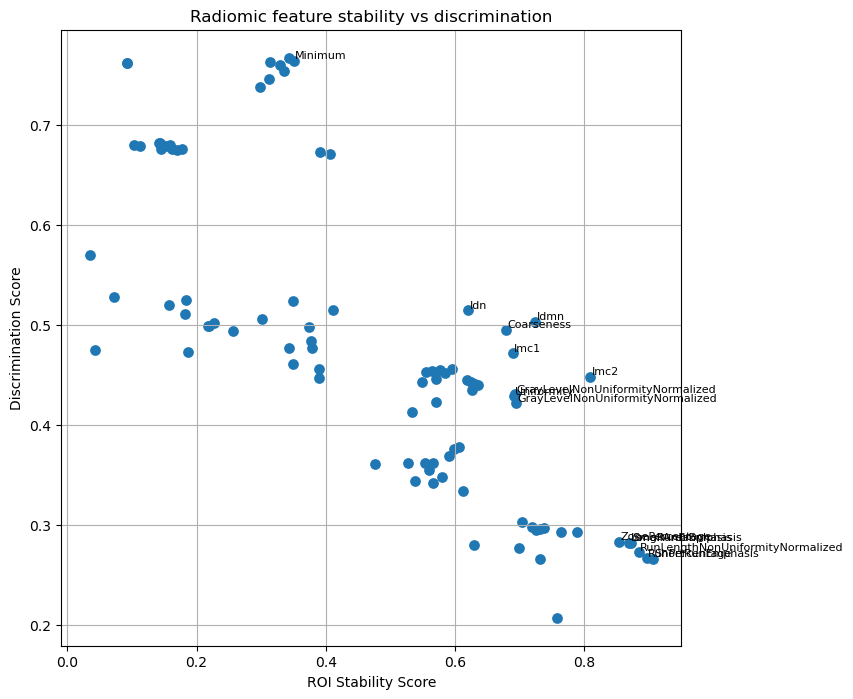

In [8]:
plt.figure(figsize=(8,8))

plt.scatter(
    combined_df["ROI0_StabilityScore"],
    combined_df["DiscriminationScore"],
    s=45
)

# Etiquetar las 15 mejores
for _, row in combined_df.head(15).iterrows():
    plt.text(
        row["ROI0_StabilityScore"]+0.002,
        row["DiscriminationScore"]+0.002,
        row["FeatureName"],
        fontsize=8
    )

plt.xlabel("ROI Stability Score")
plt.ylabel("Discrimination Score")
plt.title("Radiomic feature stability vs discrimination")

plt.grid(True)

plt.show()